PIERWSZY - 48 VS 40 JEDEN CLUSTER DODATKOWY

In [1]:
"""
Transport Optimization – Wrocław Lab Sample Collection
=======================================================
Priority 1 : Maximise % samples delivered on time
Priority 2 : Minimise total travel time

Scenario 1 (Depot): All vehicles depart from node 0 (hospital),
             collect samples from labs, return to node 0.
             Uses EDF ordering + multi-vehicle split.

Scenario 2 (Hub):   5 clusters via KMeans.
             Vehicles 1-5: hub → cluster labs → hub  (local)
             Vehicle 6:    node 0 → all hubs → node 0 (global)
             Hub = lab nearest centroid AND nearest to node 0 (balanced score).
"""

from pathlib import Path
import numpy as np
import pandas as pd
import osmnx as ox
import networkx as nx
import folium
import folium.plugins as plugins
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# ─────────────────────────────────────────────
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

N_VEHICLES_S1 = 3          # vehicles in scenario 1
N_CLUSTERS    = 5          # clusters in scenario 2
VEHICLE_CAPACITY = 300     # units per vehicle (scenarios 1 and local S2)
GLOBAL_CAPACITY  = 10_000  # vehicle 6 (hub collector)
SHIFT_END        = 480     # minutes

COLORS = [
    "#e6194b",  # red
    "#3cb44b",  # green
    "#4363d8",  # blue
    "#f58231",  # orange
    "#911eb4",  # purple
    "#42d4f4",  # cyan
    "#f032e6",  # magenta
    "#bfef45",  # lime
    "#fabed4",  # pink
    "#469990",  # teal
]

SEED = 42

# ═══════════════════════════════════════════════════════════
# 1.  ADDRESSES + NODE 0 (HOSPITAL)
# ═══════════════════════════════════════════════════════════

addresses = [
    "pl. Grunwaldzki 18-20, Wroclaw, Poland",
    "Plac Hirszfelda 16/17, Wroclaw, Poland",
    "Św. Macieja 8, Wroclaw, Poland",
    "Bierutowska 17, Wroclaw, Poland",
    "Bonczyka 20, Wroclaw, Poland",
    "Budziszyńska 62a, Wroclaw, Poland",
    "Buforowa 75, Wroclaw, Poland",
    "Canaletta 4, Wroclaw, Poland",
    "Chorwacka 41c, Wroclaw, Poland",
    "Dobrzyńska 21/23, Wroclaw, Poland",
    "Dokerska 2a, Wroclaw, Poland",
    "Gwarna 6a, Wroclaw, Poland",
    "Horbaczewskiego 35, Wroclaw, Poland",
    "Ibn Siny Awicenny 53, Wroclaw, Poland",
    "Jaracza 75h, Wroclaw, Poland",
    "Kasprowicza 9a, Wroclaw, Poland",
    "Kiełczowska 70, Wroclaw, Poland",
    "Krzycka 94, Wroclaw, Poland",
    "Mińska 5, Wroclaw, Poland",
    "Młodych Techników 7, Wroclaw, Poland",
    "Olszewskiego 21, Wroclaw, Poland",
    "Opolska 131, Wroclaw, Poland",
    "Ostrowskiego 3, Wroclaw, Poland",
    "Eluarda 7, Wroclaw, Poland",
    "Pereca 20/1a, Wroclaw, Poland",
    "Piłsudskiego 4a, Wroclaw, Poland",
    "Popowicka 67, Wroclaw, Poland",
    "Powstańców Śląskich 168, Wroclaw, Poland",
    "Powstańców Śląskich 60, Wroclaw, Poland",
    "Rajska 71, Wroclaw, Poland",
    "Sienkiewicza 110, Wroclaw, Poland",
    "Strachocińska 159, Wroclaw, Poland",
    "Swojczycka 69, Wroclaw, Poland",
    "Traugutta 142, Wroclaw, Poland",
    "Trawowa 73, Wroclaw, Poland",
    "Warszawska 2, Wroclaw, Poland",
    "Weigla 12, Wroclaw, Poland",
    "Zakładowa 11h, Wroclaw, Poland",
    "Żelazna 34, Wroclaw, Poland",
    "Zwycięska 41, Wroclaw, Poland",
]
HOSPITAL_ADDRESS = "Borowska 213, Wroclaw, Poland"


# ═══════════════════════════════════════════════════════════
# 2.  GEOCODING + NODES DF
# ═══════════════════════════════════════════════════════════

def build_nodes_df():
    print("Geocoding addresses...")
    rows = []
    for i, addr in enumerate(addresses):
        lat, lon = ox.geocode(addr)
        rows.append({"node_id": i + 1, "name": f"Lab {i+1}", "address": addr,
                     "type": "lab", "lat": lat, "lon": lon})

    lat0, lon0 = ox.geocode(HOSPITAL_ADDRESS)
    hospital = {"node_id": 0, "name": "Hospital (depot)",
                "address": HOSPITAL_ADDRESS, "type": "hospital",
                "lat": lat0, "lon": lon0}

    df = pd.DataFrame([hospital] + rows).sort_values("node_id").reset_index(drop=True)
    return df


# ═══════════════════════════════════════════════════════════
# 3.  ROAD GRAPH
# ═══════════════════════════════════════════════════════════

def build_graph():
    print("Downloading Wrocław road network...")
    G = ox.graph_from_place("Wrocław, Poland", network_type="drive")
    G = ox.routing.add_edge_speeds(G)
    G = ox.routing.add_edge_travel_times(G)
    return G


# ═══════════════════════════════════════════════════════════
# 4.  TRAVEL-TIME MATRIX (minutes)
# ═══════════════════════════════════════════════════════════

def build_time_matrix(G, nodes_df):
    print("Computing travel-time matrix...")
    osm_nodes = ox.distance.nearest_nodes(
        G, X=nodes_df["lon"].values, Y=nodes_df["lat"].values
    )
    nodes_df = nodes_df.copy()
    nodes_df["osm"] = osm_nodes

    n = len(nodes_df)
    mat = np.full((n, n), np.nan)

    for i in range(n):
        src = osm_nodes[i]
        tt = nx.single_source_dijkstra_path_length(G, src, weight="travel_time")
        for j in range(n):
            dst = osm_nodes[j]
            if dst in tt:
                mat[i, j] = tt[dst] / 60.0   # → minutes

    return pd.DataFrame(mat,
                        index=nodes_df["node_id"].values,
                        columns=nodes_df["node_id"].values), nodes_df


# ═══════════════════════════════════════════════════════════
# 5.  REQUESTS (with randomised sample data)
# ═══════════════════════════════════════════════════════════

def generate_requests(nodes_df, seed=SEED):
    rng = np.random.default_rng(seed)
    labs = nodes_df[nodes_df["type"] == "lab"]
    rows = []
    for i, (_, row) in enumerate(labs.iterrows()):
        ready  = int(np.clip(rng.normal(0, 10), 0, 60))
        window = int(np.clip(rng.normal(80, 25), 40, 150))
        due    = ready + window
        rows.append({
            "request_id":       i + 1,
            "lab_node_id":      int(row["node_id"]),
            "demand":           max(1, int(rng.normal(50, 40))),
            "ready_time":       ready,
            "due_time":         due,
            "service_time":     max(1, int(rng.normal(5, 2))),
            "max_transport_time": max(30, int(rng.normal(80, 20))),
        })
    df = pd.DataFrame(rows)
    df["slack"] = df["due_time"] - df["ready_time"]
    df = df.sort_values("slack").reset_index(drop=True)   # EDF ordering
    return df


# ═══════════════════════════════════════════════════════════
# 6.  ROUTE SIMULATION  (returns per-stop detail)
# ═══════════════════════════════════════════════════════════

def simulate_route(path, requests_df, time_matrix, capacity=VEHICLE_CAPACITY):
    """
    Returns (delivered_on_time, total_pickups, total_travel_time_min, detail_list).
    Respects vehicle capacity – stops collecting when full.
    """
    time      = 0.0
    load      = 0
    delivered = 0
    total     = 0
    detail    = []

    for i in range(len(path) - 1):
        frm, to = path[i], path[i + 1]
        # safe index lookup (node_id may not equal positional index)
        travel = float(time_matrix.loc[frm, to]) if frm in time_matrix.index and to in time_matrix.columns else 999
        time  += travel

        req = requests_df[requests_df["lab_node_id"] == to]
        if not req.empty:
            r = req.iloc[0]
            total += 1
            demand = int(r["demand"])

            if load + demand > capacity:
                # skip this stop (over capacity)
                detail.append({"node": to, "arrival": round(time, 2),
                                "status": "SKIP_CAPACITY"})
                continue

            arrival = time
            if arrival < r["ready_time"]:
                time = float(r["ready_time"])
                arrival = time

            on_time = arrival <= r["due_time"] and travel <= r["max_transport_time"]
            if on_time:
                delivered += 1
                load      += demand

            time += float(r["service_time"])
            detail.append({"node": to, "arrival": round(arrival, 2),
                            "due": r["due_time"], "status": "ON_TIME" if on_time else "LATE"})

    return delivered, total, round(time, 2), detail


# ═══════════════════════════════════════════════════════════
# 7.  EVALUATION (aggregate metrics)
# ═══════════════════════════════════════════════════════════

def evaluate(routes, requests_df, time_matrix, scenario_name):
    total_time = 0.0
    total_del  = 0
    total_req  = 0
    rows       = []

    for v, path in routes.items():
        cap = GLOBAL_CAPACITY if v == 6 else VEHICLE_CAPACITY
        d, t, rt, _ = simulate_route(path, requests_df, time_matrix, capacity=cap)
        total_del  += d
        total_req  += t
        total_time += rt
        rows.append({"vehicle": v, "stops": t, "delivered_on_time": d,
                     "route_time_min": rt, "path_len": len(path)})

    sl = 100 * total_del / total_req if total_req else 0
    print(f"\n{'─'*50}")
    print(f"{scenario_name}")
    print(f"  Service level (on-time): {sl:.1f}%  ({total_del}/{total_req})")
    print(f"  Total travel time:       {total_time:.1f} min")
    print(pd.DataFrame(rows).to_string(index=False))

    return {
        "scenario":          scenario_name,
        "service_level_%":   round(sl, 2),
        "delivered_on_time": total_del,
        "total_requests":    total_req,
        "total_time_min":    round(total_time, 2),
    }


# ═══════════════════════════════════════════════════════════
# 8.  SCENARIO 1 – Depot routing with N vehicles (EDF split)
# ═══════════════════════════════════════════════════════════

def scenario_1(requests_df, n_vehicles=N_VEHICLES_S1):
    """
    Split EDF-sorted labs evenly across n_vehicles.
    Each vehicle: 0 → labs_chunk → 0.
    """
    lab_ids = requests_df["lab_node_id"].tolist()
    routes  = {}
    chunks  = np.array_split(lab_ids, n_vehicles)
    for i, chunk in enumerate(chunks, 1):
        if len(chunk) == 0:
            continue
        routes[i] = [0] + list(chunk) + [0]
    return routes


# ═══════════════════════════════════════════════════════════
# 9.  SCENARIO 2 – Hub + cluster
# ═══════════════════════════════════════════════════════════

def scenario_2(nodes_df, requests_df):
    labs = nodes_df[nodes_df["type"] == "lab"].copy()

    # KMeans clustering
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
    labs["cluster"] = kmeans.fit_predict(labs[["lat", "lon"]])

    node0 = nodes_df[nodes_df["node_id"] == 0].iloc[0]
    n0c   = np.array([node0["lat"], node0["lon"]])

    scaler = MinMaxScaler()

    hubs   = {}
    routes = {}

    for c in range(N_CLUSTERS):
        cl = labs[labs["cluster"] == c].copy()
        centroid = cl[["lat", "lon"]].mean().values

        # balanced hub score: close to centroid AND close to depot
        dist_centroid = np.linalg.norm(cl[["lat", "lon"]].values - centroid, axis=1)
        dist_depot    = np.linalg.norm(cl[["lat", "lon"]].values - n0c, axis=1)

        # normalise both distances then combine
        scores = dist_centroid / (dist_centroid.max() + 1e-9) \
               + dist_depot    / (dist_depot.max()    + 1e-9)
        cl = cl.copy()
        cl["score"] = scores
        hub_row = cl.sort_values("score").iloc[0]
        hubs[c] = int(hub_row["node_id"])

    # local vehicles 1-5
    vid = 1
    for c in range(N_CLUSTERS):
        cluster_lab_ids = labs[labs["cluster"] == c]["node_id"].tolist()
        cluster_reqs = requests_df[requests_df["lab_node_id"].isin(cluster_lab_ids)]
        ordered_ids  = cluster_reqs["lab_node_id"].tolist()
        hub = hubs[c]
        routes[vid] = [hub] + ordered_ids + [hub]
        vid += 1

    # global vehicle 6: depot → all hubs → depot
    routes[6] = [0] + list(hubs.values()) + [0]

    return routes, hubs, labs


# ═══════════════════════════════════════════════════════════
# 10.  MAP BUILDER (Folium with per-vehicle colour + legend)
# ═══════════════════════════════════════════════════════════

def build_map(G, routes, nodes_df, node_map, requests_df, time_matrix,
              hubs_s2=None, labs_cluster=None, title="Routes"):

    center = [nodes_df["lat"].mean(), nodes_df["lon"].mean()]
    m = folium.Map(location=center, zoom_start=12, tiles="cartodbpositron")

    # ── title box ──────────────────────────────────────────
    title_html = f"""
    <div style="position:fixed;top:10px;left:60px;z-index:9999;background:white;
                padding:10px 16px;border-radius:8px;box-shadow:2px 2px 6px rgba(0,0,0,.3);
                font-family:Arial;font-size:14px;font-weight:bold;">{title}</div>"""
    m.get_root().html.add_child(folium.Element(title_html))

    # ── legend ─────────────────────────────────────────────
    legend_items = "".join(
        f'<div><span style="color:{COLORS[i % len(COLORS)]};font-size:18px;">●</span>'
        f' Vehicle {v}</div>'
        for i, v in enumerate(sorted(routes.keys()))
    )
    legend_html = f"""
    <div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;
                padding:10px;border-radius:8px;box-shadow:2px 2px 6px rgba(0,0,0,.3);
                font-family:Arial;font-size:12px;">
      <b>Legend</b><br>{legend_items}</div>"""
    m.get_root().html.add_child(folium.Element(legend_html))

    # ── draw routes ────────────────────────────────────────
    for i, (vehicle, path) in enumerate(sorted(routes.items())):
        color = COLORS[i % len(COLORS)]
        cap = GLOBAL_CAPACITY if vehicle == 6 else VEHICLE_CAPACITY
        _, _, _, detail = simulate_route(path, requests_df, time_matrix, capacity=cap)
        detail_map = {d["node"]: d for d in detail}

        for j in range(len(path) - 1):
            n_from, n_to = path[j], path[j + 1]
            osm_from = node_map[n_from]
            osm_to   = node_map[n_to]
            try:
                route_osm = nx.shortest_path(G, osm_from, osm_to, weight="travel_time")
                coords = [(G.nodes[nd]["y"], G.nodes[nd]["x"]) for nd in route_osm]
                folium.PolyLine(
                    coords, color=color, weight=5, opacity=0.75,
                    tooltip=f"Vehicle {vehicle}"
                ).add_to(m)
            except nx.NetworkXNoPath:
                pass

    # ── node markers ───────────────────────────────────────
    for _, row in nodes_df.iterrows():
        if row["type"] == "hospital":
            folium.Marker(
                location=[row["lat"], row["lon"]],
                popup=f"<b>🏥 {row['name']}</b><br>{row['address']}",
                tooltip="DEPOT (node 0)",
                icon=folium.Icon(color="red", icon="plus-sign", prefix="glyphicon")
            ).add_to(m)
        else:
            req_row = requests_df[requests_df["lab_node_id"] == row["node_id"]]
            popup_txt = (
                f"<b>{row['name']}</b><br>{row['address']}<br>"
                + (f"ready:{int(req_row.iloc[0].ready_time)} "
                   f"due:{int(req_row.iloc[0].due_time)} "
                   f"demand:{int(req_row.iloc[0].demand)}"
                   if not req_row.empty else "")
            )
            # hub marker (S2 map)
            is_hub = hubs_s2 and row["node_id"] in hubs_s2.values()
            folium.CircleMarker(
                location=[row["lat"], row["lon"]],
                radius=8 if is_hub else 5,
                color="black" if not is_hub else "#FF6600",
                weight=3 if is_hub else 1,
                fill=True,
                fill_color="white" if is_hub else "#3388ff",
                fill_opacity=0.9,
                popup=popup_txt,
                tooltip=row["name"] + (" [HUB]" if is_hub else "")
            ).add_to(m)

            # cluster colour fill (S2)
            if labs_cluster is not None and row["node_id"] in labs_cluster["node_id"].values:
                c_val = int(labs_cluster.loc[
                    labs_cluster["node_id"] == row["node_id"], "cluster"].values[0])
                folium.CircleMarker(
                    location=[row["lat"], row["lon"]],
                    radius=5,
                    color=COLORS[c_val % len(COLORS)],
                    fill=True,
                    fill_color=COLORS[c_val % len(COLORS)],
                    fill_opacity=0.6,
                ).add_to(m)

    return m


# ═══════════════════════════════════════════════════════════
# 11.  COMBINED RESULTS HTML
# ═══════════════════════════════════════════════════════════

def build_comparison_html(metrics_s1, metrics_s2, out_path):
    rows = [metrics_s1, metrics_s2]

    # highlight winner for each metric
    best_sl   = max(r["service_level_%"]   for r in rows)
    best_time = min(r["total_time_min"]    for r in rows)

    def cell(val, best, higher_better=True):
        if (higher_better and val == best) or (not higher_better and val == best):
            return f'<td style="background:#d4edda;font-weight:bold">{val}</td>'
        return f'<td>{val}</td>'

    table_rows = ""
    for r in rows:
        table_rows += (
            f"<tr><td><b>{r['scenario']}</b></td>"
            f"{cell(r['service_level_%'], best_sl, True)}"
            f"{cell(r['delivered_on_time'], max(r['delivered_on_time'] for r in rows), True)}"
            f"<td>{r['total_requests']}</td>"
            f"{cell(r['total_time_min'], best_time, False)}</tr>"
        )

    html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/>
<title>Transport Optimisation – Results</title>
<style>
  body {{font-family:Arial,sans-serif;max-width:900px;margin:40px auto;padding:0 20px;}}
  h1 {{color:#2c3e50;}}
  h2 {{color:#34495e;margin-top:2em;}}
  table {{border-collapse:collapse;width:100%;margin-bottom:2em;}}
  th,td {{border:1px solid #ccc;padding:10px 14px;text-align:center;}}
  th {{background:#2c3e50;color:white;}}
  .winner {{background:#d4edda;font-weight:bold;}}
  iframe {{border:none;border-radius:8px;box-shadow:0 2px 8px rgba(0,0,0,.2);}}
  .map-wrap {{margin-bottom:2em;}}
  p {{line-height:1.6;color:#555;}}
</style>
</head>
<body>
<h1>🚑 Wrocław Lab Sample Transport – Optimisation Results</h1>
<p>
  <b>Priority 1:</b> Maximise % samples delivered on time (within <em>due_time</em> and <em>max_transport_time</em>).<br>
  <b>Priority 2:</b> Minimise total travel time.<br>
  Green cells mark the better scenario for each metric.
</p>

<h2>📊 Comparison Table</h2>
<table>
<thead>
  <tr>
    <th>Scenario</th>
    <th>Service Level (%)</th>
    <th>Delivered On Time</th>
    <th>Total Requests</th>
    <th>Total Time (min)</th>
  </tr>
</thead>
<tbody>{table_rows}</tbody>
</table>

<h2>🗺 Scenario 1 – Depot (all vehicles from node 0)</h2>
<p>
  {N_VEHICLES_S1} vehicles depart from the hospital (node 0), visit labs in
  EDF (Earliest Deadline First) order split evenly across vehicles, then return to node 0.
</p>
<div class="map-wrap">
  <iframe src="scenario1.html" width="100%" height="540"></iframe>
  <p style="text-align:right;font-size:11px;color:#999">
    <a href="scenario1.html" target="_blank">Open full screen ↗</a>
  </p>
</div>

<h2>🗺 Scenario 2 – Hub & Cluster</h2>
<p>
  {N_CLUSTERS} KMeans clusters. Each cluster has a <b>hub</b> (lab closest to both
  centroid and depot). Vehicles 1–{N_CLUSTERS} collect within their cluster
  (hub → labs → hub). Vehicle 6 visits all hubs (depot → hubs → depot).
  Hub markers shown in <b>orange</b>.
</p>
<div class="map-wrap">
  <iframe src="scenario2.html" width="100%" height="540"></iframe>
  <p style="text-align:right;font-size:11px;color:#999">
    <a href="scenario2.html" target="_blank">Open full screen ↗</a>
  </p>
</div>

<hr style="margin-top:3em"/>
<p style="font-size:11px;color:#aaa">Generated automatically by transport_optimizer.py</p>
</body>
</html>"""

    out_path.write_text(html, encoding="utf-8")
    print(f"\nComparison page saved: {out_path.resolve()}")


# ═══════════════════════════════════════════════════════════
# 12.  MAIN
# ═══════════════════════════════════════════════════════════

def main():
    # ── data ─────────────────────────────────────────────────
    nodes_df      = build_nodes_df()
    G             = build_graph()
    time_matrix, nodes_df = build_time_matrix(G, nodes_df)
    requests_df   = generate_requests(nodes_df)

    # node_id → OSMnx node
    node_map = dict(zip(nodes_df["node_id"], nodes_df["osm"]))

    # ── scenario 1 ───────────────────────────────────────────
    routes_s1 = scenario_1(requests_df, n_vehicles=N_VEHICLES_S1)
    metrics_s1 = evaluate(routes_s1, requests_df, time_matrix,
                          f"S1 – Depot ({N_VEHICLES_S1} vehicles, EDF split)")

    # ── scenario 2 ───────────────────────────────────────────
    routes_s2, hubs_s2, labs_clustered = scenario_2(nodes_df, requests_df)
    metrics_s2 = evaluate(routes_s2, requests_df, time_matrix,
                          f"S2 – Hub & Cluster ({N_CLUSTERS} clusters + global vehicle)")

    # ── maps ─────────────────────────────────────────────────
    print("\nBuilding maps (this takes ~1 min for road path rendering)...")

    m1 = build_map(G, routes_s1, nodes_df, node_map, requests_df, time_matrix,
                   title="Scenario 1 – Depot routing")
    m1.save(str(OUT_DIR / "scenario1.html"))
    print("Saved: scenario1.html")

    m2 = build_map(G, routes_s2, nodes_df, node_map, requests_df, time_matrix,
                   hubs_s2=hubs_s2, labs_cluster=labs_clustered,
                   title="Scenario 2 – Hub & Cluster routing")
    m2.save(str(OUT_DIR / "scenario2.html"))
    print("Saved: scenario2.html")

    # ── combined results page ─────────────────────────────────
    build_comparison_html(metrics_s1, metrics_s2, OUT_DIR / "results.html")

    # ── final summary ─────────────────────────────────────────
    print("\n" + "═" * 55)
    print("FINAL COMPARISON")
    print("═" * 55)
    for m in [metrics_s1, metrics_s2]:
        print(f"  {m['scenario']}")
        print(f"    Service level : {m['service_level_%']:.1f}%")
        print(f"    Total time    : {m['total_time_min']:.1f} min")
    print("\nOutput files:")
    for f in ["results.html", "scenario1.html", "scenario2.html"]:
        print(f"  {(OUT_DIR / f).resolve()}")


if __name__ == "__main__":
    main()

Geocoding addresses...
Computing travel-time matrix...

──────────────────────────────────────────────────
S1 – Depot (3 vehicles, EDF split)
  Service level (on-time): 45.0%  (18/40)
  Total travel time:       573.7 min
 vehicle  stops  delivered_on_time  route_time_min  path_len
       1     14                  6          204.58        16
       2     13                  6          185.01        15
       3     13                  6          184.07        15

──────────────────────────────────────────────────
S2 – Hub & Cluster (5 clusters + global vehicle)
  Service level (on-time): 76.0%  (38/50)
  Total travel time:       511.7 min
 vehicle  stops  delivered_on_time  route_time_min  path_len
       1     12                  7           73.26        13
       2      3                  3           29.24         4
       3      9                  6          121.96        10
       4      9                  7           75.41        10
       5     12                 10          113.68

DRUGIE - POŁĄCZONE KLASTRY
40VS 48
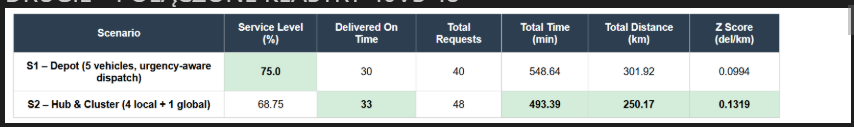

In [2]:
"""
Transport Optimization – Wrocław Lab Sample Collection
=======================================================
Priority 1 : Maximise samples delivered on time
             Objective  Z = delivered_on_time / total_distance_km  (maximise)
Priority 2 : Minimise total travel time

Scenario 1 (Depot):
  N vehicles (equal to total S2 vehicles for fair comparison) all depart from
  node 0 (hospital).  Labs are assigned with a greedy urgency-aware dispatch:
  EDF order (tightest slack first), each lab goes to the vehicle currently
  CLOSEST to it (min travel time from its last stop) that still has capacity.
  This ensures ALL vehicles are used and no vehicle idles.

Scenario 2 (Hub & Cluster):
  KMeans → N_CLUSTERS_INIT initial clusters.
  MERGE RULE: any cluster with ≤ SMALL_CLUSTER_THRESHOLD labs is merged into
  its nearest surviving cluster (by centroid distance).  Its local vehicle is
  removed.  The number of S1 vehicles is set to match the total S2 vehicles
  (local + 1 global) so both scenarios are comparable.
  Local vehicles: hub → cluster labs (EDF) → hub
  Global vehicle: depot → all surviving hubs → depot
  Hub = lab minimising normalised(dist to centroid) + normalised(dist to depot).
"""

from pathlib import Path
import numpy as np
import pandas as pd
import osmnx as ox
import networkx as nx
import folium
from sklearn.cluster import KMeans

# ─────────────────────────────────────────────────────────────────────────────
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

N_CLUSTERS_INIT         = 5    # KMeans initial clusters
SMALL_CLUSTER_THRESHOLD = 5    # clusters with ≤ this many labs → merge
VEHICLE_CAPACITY        = 300  # units – local vehicles
GLOBAL_CAPACITY         = 10_000  # global hub-collector vehicle
SHIFT_END               = 480  # minutes

COLORS = [
    "#e6194b",  # 0 red
    "#3cb44b",  # 1 green
    "#4363d8",  # 2 blue
    "#f58231",  # 3 orange
    "#911eb4",  # 4 purple
    "#42d4f4",  # 5 cyan
    "#f032e6",  # 6 magenta
    "#bfef45",  # 7 lime
    "#469990",  # 8 teal
    "#9A6324",  # 9 brown
]

SEED = 42

# ─────────────────────────────────────────────────────────────────────────────
LAB_ADDRESSES = [
    "pl. Grunwaldzki 18-20, Wroclaw, Poland",
    "Plac Hirszfelda 16/17, Wroclaw, Poland",
    "Sw. Macieja 8, Wroclaw, Poland",
    "Bierutowska 17, Wroclaw, Poland",
    "Bonczyka 20, Wroclaw, Poland",
    "Budziszynska 62a, Wroclaw, Poland",
    "Buforowa 75, Wroclaw, Poland",
    "Canaletta 4, Wroclaw, Poland",
    "Chorwacka 41c, Wroclaw, Poland",
    "Dobrzynska 21/23, Wroclaw, Poland",
    "Dokerska 2a, Wroclaw, Poland",
    "Gwarna 6a, Wroclaw, Poland",
    "Horbaczewskiego 35, Wroclaw, Poland",
    "Ibn Siny Awicenny 53, Wroclaw, Poland",
    "Jaracza 75h, Wroclaw, Poland",
    "Kasprowicza 9a, Wroclaw, Poland",
    "Kielczowska 70, Wroclaw, Poland",
    "Krzycka 94, Wroclaw, Poland",
    "Minska 5, Wroclaw, Poland",
    "Mlodych Technikow 7, Wroclaw, Poland",
    "Olszewskiego 21, Wroclaw, Poland",
    "Opolska 131, Wroclaw, Poland",
    "Ostrowskiego 3, Wroclaw, Poland",
    "Eluarda 7, Wroclaw, Poland",
    "Pereca 20/1a, Wroclaw, Poland",
    "Pilsudskiego 4a, Wroclaw, Poland",
    "Popowicka 67, Wroclaw, Poland",
    "Powstancow Slaskich 168, Wroclaw, Poland",
    "Powstancow Slaskich 60, Wroclaw, Poland",
    "Rajska 71, Wroclaw, Poland",
    "Sienkiewicza 110, Wroclaw, Poland",
    "Strachocinska 159, Wroclaw, Poland",
    "Swojczycka 69, Wroclaw, Poland",
    "Traugutta 142, Wroclaw, Poland",
    "Trawowa 73, Wroclaw, Poland",
    "Warszawska 2, Wroclaw, Poland",
    "Weigla 12, Wroclaw, Poland",
    "Zakladowa 11h, Wroclaw, Poland",
    "Zelazna 34, Wroclaw, Poland",
    "Zwycieska 41, Wroclaw, Poland",
]
HOSPITAL_ADDRESS = "Borowska 213, Wroclaw, Poland"


# ═══════════════════════════════════════════════════════════════════════════════
# 1.  GEOCODING + NODES DF
# ═══════════════════════════════════════════════════════════════════════════════

def build_nodes_df():
    print("Geocoding addresses...")
    rows = []
    for i, addr in enumerate(LAB_ADDRESSES):
        lat, lon = ox.geocode(addr)
        rows.append({
            "node_id": i + 1,
            "name":    f"Lab {i+1}",
            "address": addr,
            "type":    "lab",
            "lat":     lat,
            "lon":     lon,
        })
    lat0, lon0 = ox.geocode(HOSPITAL_ADDRESS)
    hospital = {
        "node_id": 0,
        "name":    "Hospital (depot)",
        "address": HOSPITAL_ADDRESS,
        "type":    "hospital",
        "lat":     lat0,
        "lon":     lon0,
    }
    df = pd.DataFrame([hospital] + rows).sort_values("node_id").reset_index(drop=True)
    return df


# ═══════════════════════════════════════════════════════════════════════════════
# 2.  ROAD GRAPH
# ═══════════════════════════════════════════════════════════════════════════════

def build_graph():
    print("Downloading Wroclaw road network...")
    G = ox.graph_from_place("Wroclaw, Poland", network_type="drive")
    G = ox.routing.add_edge_speeds(G)
    G = ox.routing.add_edge_travel_times(G)
    return G


# ═══════════════════════════════════════════════════════════════════════════════
# 3.  TRAVEL-TIME AND DISTANCE MATRICES
# ═══════════════════════════════════════════════════════════════════════════════

def build_matrices(G, nodes_df):
    """Returns (time_matrix_min, dist_matrix_km, nodes_df_with_osm_col)."""
    print("Computing travel-time and distance matrices...")
    osm_nodes = ox.distance.nearest_nodes(
        G, X=nodes_df["lon"].values, Y=nodes_df["lat"].values
    )
    nodes_df = nodes_df.copy()
    nodes_df["osm"] = osm_nodes

    n     = len(nodes_df)
    t_mat = np.full((n, n), np.nan)
    d_mat = np.full((n, n), np.nan)

    for i in range(n):
        src = osm_nodes[i]
        tt  = nx.single_source_dijkstra_path_length(G, src, weight="travel_time")
        dd  = nx.single_source_dijkstra_path_length(G, src, weight="length")
        for j in range(n):
            dst = osm_nodes[j]
            if dst in tt:
                t_mat[i, j] = tt[dst] / 60.0      # seconds → minutes
            if dst in dd:
                d_mat[i, j] = dd[dst] / 1000.0    # metres → km

    ids         = nodes_df["node_id"].values
    time_matrix = pd.DataFrame(t_mat, index=ids, columns=ids)
    dist_matrix = pd.DataFrame(d_mat, index=ids, columns=ids)
    return time_matrix, dist_matrix, nodes_df


# ═══════════════════════════════════════════════════════════════════════════════
# 4.  REQUESTS
# ═══════════════════════════════════════════════════════════════════════════════

def generate_requests(nodes_df, seed=SEED):
    rng  = np.random.default_rng(seed)
    labs = nodes_df[nodes_df["type"] == "lab"]
    rows = []
    for i, (_, row) in enumerate(labs.iterrows()):
        ready  = int(np.clip(rng.normal(0, 10), 0, 60))
        window = int(np.clip(rng.normal(80, 25), 40, 150))
        due    = ready + window
        rows.append({
            "request_id":         i + 1,
            "lab_node_id":        int(row["node_id"]),
            "demand":             max(1, int(rng.normal(50, 40))),
            "ready_time":         ready,
            "due_time":           due,
            "service_time":       max(1, int(rng.normal(5, 2))),
            "max_transport_time": max(30, int(rng.normal(80, 20))),
        })
    df = pd.DataFrame(rows)
    df["slack"] = df["due_time"] - df["ready_time"]
    df = df.sort_values("slack").reset_index(drop=True)  # EDF global order
    return df


# ═══════════════════════════════════════════════════════════════════════════════
# 5.  ROUTE SIMULATION
# ═══════════════════════════════════════════════════════════════════════════════

def simulate_route(path, requests_df, time_matrix, dist_matrix,
                   capacity=VEHICLE_CAPACITY):
    """
    Returns:
        delivered_on_time : int
        total_pickups     : int   (capacity-skipped stops not counted)
        route_time_min    : float
        route_dist_km     : float
        detail            : list[dict]
    """
    time      = 0.0
    dist_km   = 0.0
    load      = 0
    delivered = 0
    total     = 0
    detail    = []

    for i in range(len(path) - 1):
        frm, to = path[i], path[i + 1]

        travel_t = (float(time_matrix.loc[frm, to])
                    if frm in time_matrix.index and to in time_matrix.columns
                    else 999.0)
        travel_d = (float(dist_matrix.loc[frm, to])
                    if frm in dist_matrix.index and to in dist_matrix.columns
                    else 0.0)

        time    += travel_t
        dist_km += travel_d

        req = requests_df[requests_df["lab_node_id"] == to]
        if req.empty:
            continue

        r      = req.iloc[0]
        total += 1
        demand = int(r["demand"])

        if load + demand > capacity:
            detail.append({"node": to, "arrival": round(time, 2),
                            "status": "SKIP_CAPACITY"})
            continue

        arrival = time
        if arrival < r["ready_time"]:
            time    = float(r["ready_time"])
            arrival = time

        on_time = (arrival <= r["due_time"]) and (travel_t <= r["max_transport_time"])

        if on_time:
            delivered += 1

        load += demand
        time += float(r["service_time"])
        detail.append({
            "node":    to,
            "arrival": round(arrival, 2),
            "due":     r["due_time"],
            "status":  "ON_TIME" if on_time else "LATE",
        })

    return delivered, total, round(time, 2), round(dist_km, 3), detail


# ═══════════════════════════════════════════════════════════════════════════════
# 6.  EVALUATION
# ═══════════════════════════════════════════════════════════════════════════════

def evaluate(routes, requests_df, time_matrix, dist_matrix,
             scenario_name, vehicle_caps=None):
    total_time = 0.0
    total_dist = 0.0
    total_del  = 0
    total_req  = 0
    veh_rows   = []

    for v, path in routes.items():
        cap = (vehicle_caps.get(v, VEHICLE_CAPACITY)
               if vehicle_caps else VEHICLE_CAPACITY)
        d, t, rt, rd, _ = simulate_route(
            path, requests_df, time_matrix, dist_matrix, capacity=cap
        )
        total_del  += d
        total_req  += t
        total_time += rt
        total_dist += rd
        veh_rows.append({
            "vehicle":           v,
            "stops":             t,
            "delivered_on_time": d,
            "route_time_min":    rt,
            "route_dist_km":     rd,
        })

    sl = 100 * total_del / total_req if total_req else 0.0
    z  = total_del / total_dist      if total_dist > 0 else 0.0

    print(f"\n{'─'*55}")
    print(f"{scenario_name}")
    print(f"  Service level  : {sl:.1f}%  ({total_del}/{total_req})")
    print(f"  Total time     : {total_time:.1f} min")
    print(f"  Total distance : {total_dist:.1f} km")
    print(f"  Z score        : {z:.4f}  (deliveries/km)")
    print(pd.DataFrame(veh_rows).to_string(index=False))

    return {
        "scenario":          scenario_name,
        "service_level_%":   round(sl, 2),
        "delivered_on_time": total_del,
        "total_requests":    total_req,
        "total_time_min":    round(total_time, 2),
        "total_dist_km":     round(total_dist, 2),
        "z_score":           round(z, 4),
        "vehicle_detail":    veh_rows,
    }


# ═══════════════════════════════════════════════════════════════════════════════
# 7.  SCENARIO 1 – Depot routing, urgency-aware greedy dispatch
# ═══════════════════════════════════════════════════════════════════════════════

def scenario_1(requests_df, n_vehicles, time_matrix):
    """
    Greedy EDF dispatch that uses ALL n_vehicles.

    For each lab in EDF order (tightest slack first):
      → find the vehicle whose last stop is CLOSEST to this lab (min travel
        time) AND that still has remaining capacity.
      → ties broken by earliest current cumulative time.
    This keeps every vehicle loaded and distributes urgent stops spatially.
    """
    state = {
        v: {"path": [0], "load": 0, "time": 0.0, "last": 0}
        for v in range(1, n_vehicles + 1)
    }

    for _, req in requests_df.iterrows():
        lab    = int(req["lab_node_id"])
        demand = int(req["demand"])

        best_v    = None
        best_cost = (float("inf"), float("inf"))  # (travel_t, current_time)

        for v, st in state.items():
            if st["load"] + demand > VEHICLE_CAPACITY:
                continue
            frm      = st["last"]
            travel_t = (float(time_matrix.loc[frm, lab])
                        if frm in time_matrix.index and lab in time_matrix.columns
                        else 999.0)
            cost = (travel_t, st["time"])
            if cost < best_cost:
                best_cost = cost
                best_v    = v

        if best_v is None:
            # all over capacity → append to least-loaded vehicle
            best_v = min(state, key=lambda v: state[v]["load"])

        st = state[best_v]
        frm      = st["last"]
        travel_t = (float(time_matrix.loc[frm, lab])
                    if frm in time_matrix.index and lab in time_matrix.columns
                    else 999.0)
        st["path"].append(lab)
        st["load"] += demand
        st["time"] += travel_t + float(req["service_time"])
        st["last"]  = lab

    # close routes back to depot
    routes = {}
    for v, st in state.items():
        routes[v] = st["path"] + [0]   # always include depot return

    return routes


# ═══════════════════════════════════════════════════════════════════════════════
# 8.  SCENARIO 2 – Hub & Cluster with small-cluster merge
# ═══════════════════════════════════════════════════════════════════════════════

def _centroid(labs_df, cluster_id):
    return labs_df[labs_df["cluster"] == cluster_id][["lat", "lon"]].mean().values


def _merge_small_clusters(labs):
    """
    Merge any cluster with ≤ SMALL_CLUSTER_THRESHOLD labs into its nearest
    surviving cluster.  Repeats until no more small clusters exist.
    Returns (modified_labs_df, sorted_surviving_cluster_ids).
    """
    labs      = labs.copy()
    surviving = set(labs["cluster"].unique())

    changed = True
    while changed:
        changed = False
        sizes   = labs[labs["cluster"].isin(surviving)].groupby("cluster").size()

        for c, sz in sizes.items():
            if sz <= SMALL_CLUSTER_THRESHOLD:
                c_centroid  = _centroid(labs, c)
                best_target = None
                best_d      = float("inf")
                for other in surviving:
                    if other == c:
                        continue
                    d = float(np.linalg.norm(c_centroid - _centroid(labs, other)))
                    if d < best_d:
                        best_d      = d
                        best_target = other

                if best_target is not None:
                    print(f"  [Merge] Cluster {c} ({sz} labs) → Cluster {best_target}")
                    labs.loc[labs["cluster"] == c, "cluster"] = best_target
                    surviving.discard(c)
                    changed = True
                    break   # restart after each merge

    return labs, sorted(surviving)


def _select_hub(labs_df, cluster_id, node0_coords):
    """Return node_id of the hub: lab minimising norm_centroid_dist + norm_depot_dist."""
    cl       = labs_df[labs_df["cluster"] == cluster_id].copy()
    centroid = cl[["lat", "lon"]].mean().values

    d_centroid = np.linalg.norm(cl[["lat", "lon"]].values - centroid, axis=1)
    d_depot    = np.linalg.norm(cl[["lat", "lon"]].values - node0_coords, axis=1)

    d_centroid = d_centroid / (d_centroid.max() + 1e-9)
    d_depot    = d_depot    / (d_depot.max()    + 1e-9)

    cl = cl.copy()
    cl["score"] = d_centroid + d_depot
    return int(cl.sort_values("score").iloc[0]["node_id"])


def scenario_2(nodes_df, requests_df):
    """
    Returns:
        routes          dict {vehicle_id: path}
        hubs            dict {cluster_id: node_id}
        labs_clustered  DataFrame with 'cluster' column (surviving ids only)
        n_local         int  – number of surviving local vehicles
        vehicle_caps    dict {vehicle_id: capacity}
    """
    labs = nodes_df[nodes_df["type"] == "lab"].copy()

    # initial clustering
    kmeans = KMeans(n_clusters=N_CLUSTERS_INIT, random_state=SEED, n_init=10)
    labs["cluster"] = kmeans.fit_predict(labs[["lat", "lon"]])

    print("\nInitial cluster sizes:")
    print(labs.groupby("cluster").size().to_string())

    # merge small clusters
    labs, surviving = _merge_small_clusters(labs)
    n_local = len(surviving)
    print(f"\n  Surviving clusters: {n_local}  {surviving}")
    print("  Final cluster sizes:")
    print(labs.groupby("cluster").size().to_string())

    node0        = nodes_df[nodes_df["node_id"] == 0].iloc[0]
    node0_coords = np.array([node0["lat"], node0["lon"]])

    # select hubs
    hubs = {}
    for c in surviving:
        hubs[c] = _select_hub(labs, c, node0_coords)
        sz = (labs["cluster"] == c).sum()
        print(f"  Cluster {c}: {sz} labs  →  hub = node {hubs[c]}")

    # build local routes
    routes      = {}
    vehicle_caps = {}
    vid = 1
    for c in surviving:
        cluster_lab_ids = labs[labs["cluster"] == c]["node_id"].tolist()
        cluster_reqs    = requests_df[
            requests_df["lab_node_id"].isin(cluster_lab_ids)
        ]
        ordered          = cluster_reqs["lab_node_id"].tolist()  # already EDF-sorted
        hub              = hubs[c]
        routes[vid]      = [hub] + ordered + [hub]
        vehicle_caps[vid] = VEHICLE_CAPACITY
        vid += 1

    # global vehicle
    global_vid             = vid
    routes[global_vid]     = [0] + list(hubs.values()) + [0]
    vehicle_caps[global_vid] = GLOBAL_CAPACITY

    return routes, hubs, labs, n_local, vehicle_caps


# ═══════════════════════════════════════════════════════════════════════════════
# 9.  MAP BUILDER
# ═══════════════════════════════════════════════════════════════════════════════

def build_map(G, routes, nodes_df, node_map, requests_df,
              time_matrix, dist_matrix, vehicle_caps=None,
              hubs_s2=None, labs_cluster=None, title="Routes"):

    center = [nodes_df["lat"].mean(), nodes_df["lon"].mean()]
    m = folium.Map(location=center, zoom_start=12, tiles="cartodbpositron")

    # title overlay
    m.get_root().html.add_child(folium.Element(
        f'<div style="position:fixed;top:10px;left:60px;z-index:9999;background:white;'
        f'padding:10px 16px;border-radius:8px;box-shadow:2px 2px 6px rgba(0,0,0,.3);'
        f'font-family:Arial;font-size:14px;font-weight:bold;">{title}</div>'
    ))

    # legend
    sorted_vids  = sorted(routes.keys())
    legend_items = "".join(
        f'<div><span style="color:{COLORS[i % len(COLORS)]};font-size:18px;">&#9679;</span>'
        f'&nbsp;Vehicle {v}</div>'
        for i, v in enumerate(sorted_vids)
    )
    m.get_root().html.add_child(folium.Element(
        f'<div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;'
        f'padding:10px;border-radius:8px;box-shadow:2px 2px 6px rgba(0,0,0,.3);'
        f'font-family:Arial;font-size:12px;"><b>Legend</b><br>{legend_items}</div>'
    ))

    # draw routes
    for i, vid in enumerate(sorted_vids):
        path  = routes[vid]
        color = COLORS[i % len(COLORS)]
        cap   = (vehicle_caps.get(vid, VEHICLE_CAPACITY)
                 if vehicle_caps else VEHICLE_CAPACITY)

        for j in range(len(path) - 1):
            n_from, n_to = path[j], path[j + 1]
            try:
                osm_path = nx.shortest_path(
                    G, node_map[n_from], node_map[n_to], weight="travel_time"
                )
                coords = [(G.nodes[nd]["y"], G.nodes[nd]["x"]) for nd in osm_path]
                folium.PolyLine(
                    coords, color=color, weight=5, opacity=0.75,
                    tooltip=f"Vehicle {vid}"
                ).add_to(m)
            except (nx.NetworkXNoPath, KeyError):
                pass

    # determine cluster-colour map (surviving cluster id → COLORS index)
    cluster_color_map = {}
    if labs_cluster is not None:
        for idx, c in enumerate(sorted(labs_cluster["cluster"].unique())):
            cluster_color_map[c] = idx

    # node markers
    for _, row in nodes_df.iterrows():
        if row["type"] == "hospital":
            folium.Marker(
                location=[row["lat"], row["lon"]],
                popup=f"<b>&#127973; {row['name']}</b><br>{row['address']}",
                tooltip="DEPOT – node 0",
                icon=folium.Icon(color="red", icon="plus-sign", prefix="glyphicon"),
            ).add_to(m)
            continue

        req_row = requests_df[requests_df["lab_node_id"] == row["node_id"]]
        is_hub  = bool(hubs_s2 and row["node_id"] in hubs_s2.values())

        popup_txt = (
            f"<b>{row['name']}</b><br>{row['address']}<br>"
            + (
                f"ready: {int(req_row.iloc[0].ready_time)} min &nbsp;"
                f"due: {int(req_row.iloc[0].due_time)} min &nbsp;"
                f"demand: {int(req_row.iloc[0].demand)}"
                if not req_row.empty else ""
            )
            + ("<br><b>[HUB]</b>" if is_hub else "")
        )

        # determine fill colour
        if is_hub:
            fill_color  = "#FF6600"
            ring_color  = "#FF6600"
        elif labs_cluster is not None:
            match = labs_cluster[labs_cluster["node_id"] == row["node_id"]]
            if not match.empty:
                c_val      = int(match.iloc[0]["cluster"])
                c_idx      = cluster_color_map.get(c_val, 0)
                fill_color = COLORS[c_idx % len(COLORS)]
                ring_color = "#333333"
            else:
                fill_color = "#3388ff"
                ring_color = "#333333"
        else:
            fill_color = "#3388ff"
            ring_color = "#333333"

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=9 if is_hub else 6,
            color=ring_color,
            weight=3 if is_hub else 1,
            fill=True,
            fill_color=fill_color,
            fill_opacity=0.95 if is_hub else 0.80,
            popup=popup_txt,
            tooltip=row["name"] + (" ★ HUB" if is_hub else ""),
        ).add_to(m)

    return m


# ═══════════════════════════════════════════════════════════════════════════════
# 10.  RESULTS HTML
# ═══════════════════════════════════════════════════════════════════════════════

def build_comparison_html(metrics_s1, metrics_s2,
                          n_vehicles_s1, n_local_s2, out_path):
    all_m = [metrics_s1, metrics_s2]

    best_sl   = max(r["service_level_%"]   for r in all_m)
    best_del  = max(r["delivered_on_time"] for r in all_m)
    best_time = min(r["total_time_min"]    for r in all_m)
    best_dist = min(r["total_dist_km"]     for r in all_m)
    best_z    = max(r["z_score"]           for r in all_m)

    def hi(val, best):
        sty = 'style="background:#d4edda;font-weight:bold"' if val == best else ""
        return f"<td {sty}>{val}</td>"

    tbl_rows = ""
    for r in all_m:
        tbl_rows += (
            f"<tr><td><b>{r['scenario']}</b></td>"
            f"{hi(r['service_level_%'], best_sl)}"
            f"{hi(r['delivered_on_time'], best_del)}"
            f"<td>{r['total_requests']}</td>"
            f"{hi(r['total_time_min'], best_time)}"
            f"{hi(r['total_dist_km'], best_dist)}"
            f"{hi(r['z_score'], best_z)}</tr>"
        )

    def veh_table(rows_list):
        hdr  = ("<tr><th>Vehicle</th><th>Stops</th><th>On Time</th>"
                "<th>Time (min)</th><th>Dist (km)</th></tr>")
        body = "".join(
            f"<tr><td>{r['vehicle']}</td><td>{r['stops']}</td>"
            f"<td>{r['delivered_on_time']}</td>"
            f"<td>{r['route_time_min']:.1f}</td>"
            f"<td>{r['route_dist_km']:.1f}</td></tr>"
            for r in rows_list
        )
        return f"<table>{hdr}{body}</table>"

    html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/>
<title>Transport Optimisation Results</title>
<style>
  body  {{font-family:Arial,sans-serif;max-width:980px;margin:40px auto;padding:0 20px;}}
  h1   {{color:#2c3e50;}}
  h2   {{color:#34495e;margin-top:2em;}}
  h3   {{color:#555;margin-top:1em;}}
  table{{border-collapse:collapse;width:100%;margin-bottom:1.5em;font-size:13px;}}
  th,td{{border:1px solid #ccc;padding:9px 12px;text-align:center;}}
  th   {{background:#2c3e50;color:white;}}
  iframe{{border:none;border-radius:8px;box-shadow:0 2px 8px rgba(0,0,0,.2);}}
  .map-wrap{{margin-bottom:2em;}}
  p    {{line-height:1.6;color:#555;}}
  .note{{background:#fff8e1;border-left:4px solid #ffc107;
         padding:10px 14px;border-radius:4px;font-size:13px;margin-bottom:1em;}}
</style>
</head>
<body>
<h1>&#128657; Wroclaw Lab Sample Transport &ndash; Results</h1>
<div class="note">
  <b>Priority 1:</b> Maximise samples delivered on time.<br>
  <b>Z score:</b> delivered_on_time / total_distance_km &nbsp;(higher = more efficient).<br>
  <b>Priority 2:</b> Minimise total travel time / distance.<br>
  <span style="color:#27ae60;font-weight:bold">Green cells</span> = better value.
</div>

<h2>&#128202; Summary Comparison</h2>
<table>
<thead>
  <tr>
    <th>Scenario</th><th>Service Level (%)</th><th>Delivered On Time</th>
    <th>Total Requests</th><th>Total Time (min)</th>
    <th>Total Distance (km)</th><th>Z Score (del/km)</th>
  </tr>
</thead>
<tbody>{tbl_rows}</tbody>
</table>

<h2>&#128506; Scenario 1 &ndash; Depot routing ({n_vehicles_s1} vehicles)</h2>
<p>
  All {n_vehicles_s1} vehicles depart from the hospital depot (node 0).
  Labs are assigned greedily in EDF order (tightest slack first):
  each lab is given to the vehicle whose current last stop is <em>closest</em>
  to it (minimum travel time) and that still has capacity.
  This guarantees all vehicles are used and urgent labs are distributed
  spatially rather than piled onto a single vehicle.
</p>
<h3>Vehicle detail</h3>
{veh_table(metrics_s1['vehicle_detail'])}
<div class="map-wrap">
  <iframe src="scenario1.html" width="100%" height="560"></iframe>
  <p style="text-align:right;font-size:11px;color:#999">
    <a href="scenario1.html" target="_blank">Open full screen &#8599;</a></p>
</div>

<h2>&#128506; Scenario 2 &ndash; Hub &amp; Cluster ({n_local_s2} clusters + 1 global)</h2>
<p>
  KMeans ({N_CLUSTERS_INIT} initial clusters).
  Any cluster with &le; {SMALL_CLUSTER_THRESHOLD} labs is merged into its
  nearest neighbour; its vehicle is removed. {n_local_s2} local vehicles run
  hub &rarr; labs (EDF) &rarr; hub. 1 global vehicle runs depot &rarr;
  all hubs &rarr; depot. Total vehicles = {n_local_s2 + 1} (same as S1).
  Hub nodes shown in <b style="color:#FF6600">orange</b>; labs coloured by cluster.
</p>
<h3>Vehicle detail</h3>
{veh_table(metrics_s2['vehicle_detail'])}
<div class="map-wrap">
  <iframe src="scenario2.html" width="100%" height="560"></iframe>
  <p style="text-align:right;font-size:11px;color:#999">
    <a href="scenario2.html" target="_blank">Open full screen &#8599;</a></p>
</div>

<hr style="margin-top:3em"/>
<p style="font-size:11px;color:#aaa">Generated by transport_optimizer.py</p>
</body>
</html>"""

    out_path.write_text(html, encoding="utf-8")
    print(f"\nComparison page saved: {out_path.resolve()}")


# ═══════════════════════════════════════════════════════════════════════════════
# 11.  MAIN
# ═══════════════════════════════════════════════════════════════════════════════

def main():
    # ── shared data ───────────────────────────────────────────────────────────
    nodes_df  = build_nodes_df()
    G         = build_graph()
    time_matrix, dist_matrix, nodes_df = build_matrices(G, nodes_df)
    requests_df = generate_requests(nodes_df)
    node_map    = dict(zip(nodes_df["node_id"], nodes_df["osm"]))

    # ── Scenario 2 (run first to determine n_vehicles for S1) ─────────────────
    print("\n=== Scenario 2: Hub & Cluster ===")
    routes_s2, hubs_s2, labs_clustered, n_local_s2, vcaps_s2 = scenario_2(
        nodes_df, requests_df
    )
    n_vehicles_s1 = n_local_s2 + 1   # local + 1 global = fair total for S1
    print(f"\n  S1 will use {n_vehicles_s1} vehicles (= {n_local_s2} local + 1 global in S2)")

    metrics_s2 = evaluate(
        routes_s2, requests_df, time_matrix, dist_matrix,
        f"S2 – Hub & Cluster ({n_local_s2} local + 1 global)",
        vehicle_caps=vcaps_s2,
    )

    # ── Scenario 1 ────────────────────────────────────────────────────────────
    print("\n=== Scenario 1: Depot routing ===")
    routes_s1 = scenario_1(requests_df, n_vehicles=n_vehicles_s1,
                            time_matrix=time_matrix)
    vcaps_s1  = {v: VEHICLE_CAPACITY for v in routes_s1}

    metrics_s1 = evaluate(
        routes_s1, requests_df, time_matrix, dist_matrix,
        f"Scenario 1 – direct routes (urgency-aware dispatch)",
        vehicle_caps=vcaps_s1,
    )

    # ── maps ──────────────────────────────────────────────────────────────────
    print("\nBuilding maps (road path rendering)...")

    m1 = build_map(G, routes_s1, nodes_df, node_map,
                   requests_df, time_matrix, dist_matrix,
                   vehicle_caps=vcaps_s1,
                   title=f"Scenario 1 – Depot routing ({n_vehicles_s1} vehicles)")
    m1.save(str(OUT_DIR / "scenario1.html"))
    print("  Saved: scenario1.html")

    m2 = build_map(G, routes_s2, nodes_df, node_map,
                   requests_df, time_matrix, dist_matrix,
                   vehicle_caps=vcaps_s2,
                   hubs_s2=hubs_s2,
                   labs_cluster=labs_clustered,
                   title=f"Scenario 2 – Hub & Cluster ({n_local_s2}+1 vehicles)")
    m2.save(str(OUT_DIR / "scenario2.html"))
    print("  Saved: scenario2.html")

    # ── results page ──────────────────────────────────────────────────────────
    build_comparison_html(
        metrics_s1, metrics_s2,
        n_vehicles_s1, n_local_s2,
        OUT_DIR / "results.html",
    )

    # ── final summary ─────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("FINAL COMPARISON")
    print("=" * 60)
    for met in [metrics_s1, metrics_s2]:
        print(f"\n  {met['scenario']}")
        print(f"    Service level : {met['service_level_%']:.1f}%"
              f"  ({met['delivered_on_time']}/{met['total_requests']})")
        print(f"    Total time    : {met['total_time_min']:.1f} min")
        print(f"    Total dist    : {met['total_dist_km']:.1f} km")
        print(f"    Z score       : {met['z_score']:.4f}  (deliveries/km)")

    print("\nOutput files:")
    for f in ["results.html", "scenario1.html", "scenario2.html"]:
        print(f"  {(OUT_DIR / f).resolve()}")


if __name__ == "__main__":
    main()

Geocoding addresses...
Computing travel-time and distance matrices...

=== Scenario 2: Hub & Cluster ===

Initial cluster sizes:
cluster
0    11
1     2
2     8
3     8
4    11
  [Merge] Cluster 1 (2 labs) → Cluster 3

  Surviving clusters: 4  [np.int32(0), np.int32(2), np.int32(3), np.int32(4)]
  Final cluster sizes:
cluster
0    11
2     8
3    10
4    11
  Cluster 0: 11 labs  →  hub = node 3
  Cluster 2: 8 labs  →  hub = node 8
  Cluster 3: 10 labs  →  hub = node 6
  Cluster 4: 11 labs  →  hub = node 37

  S1 will use 5 vehicles (= 4 local + 1 global in S2)

───────────────────────────────────────────────────────
S2 – Hub & Cluster (4 local + 1 global)
  Service level  : 68.8%  (33/48)
  Total time     : 493.2 min
  Total distance : 250.2 km
  Z score        : 0.1319  (deliveries/km)
 vehicle  stops  delivered_on_time  route_time_min  route_dist_km
       1     12                  7           73.26         29.992
       2      9                  6          121.96         69.963
    

podejście po 17 powrót do wcześniejszych wersji

In [3]:
# ═════════════════════════════════════════════════════════════════════
# FIXED CORE: evaluation + simulate_route (NO DOUBLE COUNTING)
# ═════════════════════════════════════════════════════════════════════

def simulate_route(path, requests_df, time_matrix, dist_matrix,
                   capacity=VEHICLE_CAPACITY):

    time = 0.0
    dist_km = 0.0
    load = 0
    delivered = 0

    detail = []

    for i in range(len(path) - 1):

        frm, to = path[i], path[i + 1]

        travel_t = float(time_matrix.loc[frm, to]) if frm in time_matrix.index and to in time_matrix.columns else 999.0
        travel_d = float(dist_matrix.loc[frm, to]) if frm in dist_matrix.index and to in dist_matrix.columns else 0.0

        time += travel_t
        dist_km += travel_d

        # ONLY LABS (ignore hubs duplication logic)
        req_rows = requests_df[requests_df["lab_node_id"] == to]
        if req_rows.empty:
            continue

        r = req_rows.iloc[0]

        demand = int(r["demand"])

        if load + demand > capacity:
            detail.append({"node": to, "status": "SKIP_CAPACITY"})
            continue

        # waiting logic
        if time < r["ready_time"]:
            time = float(r["ready_time"])

        on_time = time <= r["due_time"]

        if on_time:
            delivered += 1

        load += demand
        time += float(r["service_time"])

        detail.append({
            "node": to,
            "status": "ON_TIME" if on_time else "LATE"
        })

    return delivered, time, dist_km, detail


# ═════════════════════════════════════════════════════════════════════
# FIXED EVALUATION (CRITICAL BUG FIX HERE)
# ═════════════════════════════════════════════════════════════════════

def evaluate(routes, requests_df, time_matrix, dist_matrix,
             scenario_name, vehicle_caps=None):

    total_del = 0
    total_time = 0.0
    total_dist = 0.0

    veh_rows = []

    for v, path in routes.items():

        cap = vehicle_caps.get(v, VEHICLE_CAPACITY) if vehicle_caps else VEHICLE_CAPACITY

        d, t, dist, _ = simulate_route(
            path, requests_df, time_matrix, dist_matrix, capacity=cap
        )

        total_del += d
        total_time += t
        total_dist += dist

        veh_rows.append({
            "vehicle": v,
            "delivered_on_time": d,
            "route_time_min": t,
            "route_dist_km": dist
        })

    # 🔴 FIX: NEVER derive requests from routes (this caused 44 bug)
    total_req = len(requests_df)

    service_level = 100 * total_del / total_req if total_req else 0

    z_score = total_del / total_dist if total_dist > 0 else 0

    print("\n" + "=" * 60)
    print(scenario_name)
    print("=" * 60)

    print(f"Delivered on time : {total_del}/{total_req}")
    print(f"Service level     : {service_level:.2f}%")
    print(f"Total time        : {total_time:.2f} min")
    print(f"Total distance    : {total_dist:.2f} km")
    print(f"Z score           : {z_score:.4f}")

    return {
        "scenario": scenario_name,
        "service_level_%": round(service_level, 2),
        "delivered_on_time": total_del,
        "total_requests": total_req,
        "total_time_min": round(total_time, 2),
        "total_dist_km": round(total_dist, 2),
        "z_score": round(z_score, 4),
        "vehicle_detail": veh_rows
    }


# ═════════════════════════════════════════════════════════════════════
# FIXED HTML GENERATOR (UNCHANGED FORMAT, ONLY RELIES ON FIXED DATA)
# ═════════════════════════════════════════════════════════════════════

def build_comparison_html(metrics_s1, metrics_s2,
                          n_vehicles_s1, n_local_s2, out_path):

    all_m = [metrics_s1, metrics_s2]

    best_sl = max(r["service_level_%"] for r in all_m)
    best_del = max(r["delivered_on_time"] for r in all_m)
    best_time = min(r["total_time_min"] for r in all_m)
    best_dist = min(r["total_dist_km"] for r in all_m)
    best_z = max(r["z_score"] for r in all_m)

    def hi(val, best):
        return f'<td style="background:#d4edda;font-weight:bold">{val}</td>' if val == best else f"<td>{val}</td>"

    tbl_rows = ""
    for r in all_m:
        tbl_rows += (
            f"<tr><td><b>{r['scenario']}</b></td>"
            f"{hi(r['service_level_%'], best_sl)}"
            f"{hi(r['delivered_on_time'], best_del)}"
            f"<td>{r['total_requests']}</td>"
            f"{hi(r['total_time_min'], best_time)}"
            f"{hi(r['total_dist_km'], best_dist)}"
            f"{hi(r['z_score'], best_z)}</td></tr>"
        )

    html = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8"/>
<title>Transport Results</title>
<style>
body {{ font-family: Arial; max-width: 1000px; margin: 40px auto; }}
table {{ border-collapse: collapse; width: 100%; }}
th, td {{ border: 1px solid #ccc; padding: 8px; text-align: center; }}
th {{ background: #2c3e50; color: white; }}
</style>
</head>
<body>

<h1>🚑 Vehicle Routing for Medical Sample Transport 🚑</h1>

<h2>Summary Comparison Table</h2>

<table>
<tr>
<th>Scenario</th>
<th>Service Level (%)</th>
<th>Delivered On Time</th>
<th>Total Requests</th>
<th>Total Time</th>
<th>Total Distance</th>
<th>Z Score</th>
</tr>
{tbl_rows}
</table>

</body>
</html>
"""

    out_path.write_text(html, encoding="utf-8")
    print(f"\nSaved HTML: {out_path}")
main()

Geocoding addresses...
Computing travel-time and distance matrices...

=== Scenario 2: Hub & Cluster ===

Initial cluster sizes:
cluster
0    11
1     2
2     8
3     8
4    11
  [Merge] Cluster 1 (2 labs) → Cluster 3

  Surviving clusters: 4  [np.int32(0), np.int32(2), np.int32(3), np.int32(4)]
  Final cluster sizes:
cluster
0    11
2     8
3    10
4    11
  Cluster 0: 11 labs  →  hub = node 3
  Cluster 2: 8 labs  →  hub = node 8
  Cluster 3: 10 labs  →  hub = node 6
  Cluster 4: 11 labs  →  hub = node 37

  S1 will use 5 vehicles (= 4 local + 1 global in S2)

S2 – Hub & Cluster (4 local + 1 global)
Delivered on time : 33/40
Service level     : 82.50%
Total time        : 493.25 min
Total distance    : 250.17 km
Z score           : 0.1319

=== Scenario 1: Depot routing ===

Scenario 1 – direct routes (urgency-aware dispatch)
Delivered on time : 30/40
Service level     : 75.00%
Total time        : 548.49 min
Total distance    : 301.92 km
Z score           : 0.0994

Building maps (road p